In [4]:

# Set working directory to project root regardless of where notebook is run from
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.dirname(notebook_dir)
os.chdir(project_root)
print(os.getcwd())

/Users/douglas/Documents/GitHub/claims_readmission_analysis


In [2]:
import mysql.connector
from dotenv import load_dotenv
import os

# connect notebook to sql database

load_dotenv()

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password=os.getenv('MYSQL_PASSWORD'),
    database='claims_practice'
)

print("Connection successful" if conn.is_connected() else "Connection failed")

Connection successful


## Benchmark Reference

2010 national benchmark rates for comparison:

| Condition | National Benchmark Rate |
|-----------|------------------------|
| Heart Failure | 24.8% |
| COPD | 20.8% |
| Pneumonia | 16.4% |
| AMI | 15.6% |

**Source:** Rachoin, J.-S., Hunter, K., Varallo, J., & Cerceo, E. (2024). Impact of time from discharge to readmission on outcomes: an observational study from the US National Readmission Database. *BMJ Open, 14*(8), e085466. https://doi.org/10.1136/bmjopen-2024-085466

> Note: These are risk-standardized national rates from 2010, the start of the DE-SynPUF observation period. Observed rates in this analysis are crude (not risk-standardized) and come from synthetic data — direct comparison should be interpreted cautiously.

In [5]:
import pandas as pd

# Verify df read properly with head()

with open('queries/11_hrrp_condition_readmission_rates.sql', 'r') as f:
    query = f.read()


df = pd.read_sql(query, conn)
print(df.head())

/var/folders/4_/dbg0kzhn7354xv35_by_4slr0000gn/T/ipykernel_26797/4020729497.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


  mapped_HRRP_diagnosis  readmission_rate  total_admissions
0         Heart Failure              11.0              2175
1             Pneumonia              10.6              2353
2                  COPD               9.5              1389
3                   AMI               9.4               747


In [14]:
# create a benchmark dictionary of the four conditions with cited readmission rate averages

benchmark_rates = {'Heart Failure':24.8,'Pneumonia': 16.4, 'COPD':20.8,'AMI':15.6 }

print(f'benchmark rates dictionary: {benchmark_rates}')

benchmark rates dictionary: {'Heart Failure': 24.8, 'Pneumonia': 16.4, 'COPD': 20.8, 'AMI': 15.6}


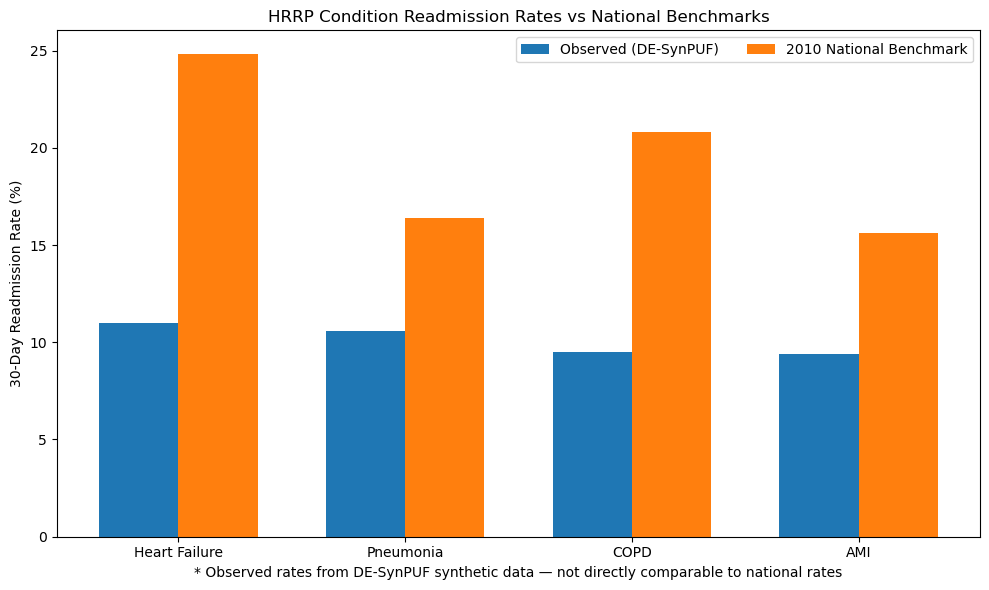

In [17]:
import matplotlib.pyplot as plt
import numpy as np

conditions = df['mapped_HRRP_diagnosis'].tolist()
observed = df['readmission_rate'].tolist()
benchmarks = [benchmark_rates[c] for c in conditions]
x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, observed, width, label='Observed (DE-SynPUF)')
bars2 = ax.bar(x + width/2, benchmarks, width, label='2010 National Benchmark')

ax.set_ylabel('30-Day Readmission Rate (%)')
ax.set_title('HRRP Condition Readmission Rates vs National Benchmarks')
ax.set_xlabel('* Observed rates from DE-SynPUF synthetic data — not directly comparable to national rates')
ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.legend(loc='upper right', ncols=4)
plt.tight_layout()
plt.savefig('images/hrrp_condition_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()